# Notebook 1 — Entraînement YOLOv8 pour la détection de défauts PCB (Transfer Learning)

## Objectif
- Charger un dataset d’images PCB et leurs annotations.
- Vérifier la cohérence du dataset (images/labels).
- Visualiser les annotations (bbox + noms de classes).
- Calculer des statistiques (répartition des classes, nb de bbox, etc.).
- Convertir les annotations (xyxy pixels) vers le format YOLO (normalisé).
- Créer la structure YOLO train/val/test + fichier YAML.
- Entraîner un modèle YOLOv8 pré-entraîné (fine-tuning).
- Sauvegarder le meilleur modèle.


# 1) Setup + Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")
IMG_DIR   = BASE / "img"
LABEL_DIR = BASE / "annotation"

assert IMG_DIR.exists(), "Dossier images introuvable"
assert LABEL_DIR.exists(), "Dossier annotations introuvable"

print("Images:", IMG_DIR)
print("Labels:", LABEL_DIR)

CLASS_NAMES_ID = {
    1: "open",
    2: "short",
    3: "mousebite",
    4: "spur",
    5: "copper",
    6: "pine_hole",
}
NAMES_YOLO = ["open","short","mousebite","spur","copper","pine_hole"]
NC = len(NAMES_YOLO)
print("NC:", NC, NAMES_YOLO)

Mounted at /content/drive
Images: /content/drive/MyDrive/COMPUTER VISION/dataset/img
Labels: /content/drive/MyDrive/COMPUTER VISION/dataset/annotation
NC: 6 ['open', 'short', 'mousebite', 'spur', 'copper', 'pine_hole']


# 2) Vérification de cohérence (images / labels)
Objectif : s’assurer que chaque image possède un fichier .txt correspondant (et inversement).


In [ ]:
img_ext = {".jpg", ".jpeg", ".png", ".bmp"}

images = sorted([p for p in IMG_DIR.iterdir() if p.suffix.lower() in img_ext])
labels = sorted([p for p in LABEL_DIR.iterdir() if p.suffix.lower() == ".txt"])

img_stems = {p.stem for p in images}
lab_stems = {p.stem for p in labels}

missing_labels = sorted(list(img_stems - lab_stems))
missing_images = sorted(list(lab_stems - img_stems))

print("Nb images:", len(images))
print("Nb labels:", len(labels))
print("Images sans label:", len(missing_labels))
print("Labels sans image:", len(missing_images))

if missing_labels[:10]:
    print("Exemples images sans label:", missing_labels[:10])
if missing_images[:10]:
    print("Exemples labels sans image:", missing_images[:10])

assert len(missing_labels) == 0, "Il y a des images sans annotation !"
assert len(missing_images) == 0, "Il y a des labels sans image !"

print("Dataset cohérent (clean).")

Nb images: 1500
Nb labels: 1500
Images sans label: 0
Labels sans image: 0
Dataset cohérent (clean).


# 3) Détection automatique du format des annotations
Deux cas possibles :
- **Format A (xyxycls pixels)** : `x1 y1 x2 y2 class_id` (en pixels)
- **Format B (YOLO normalisé)** : `class_id x_center y_center width height` (entre 0 et 1)


In [ ]:
def read_rows(txt_path: Path):
    lines = [ln.strip() for ln in txt_path.read_text().splitlines() if ln.strip()]
    return [ln.split() for ln in lines]

def detect_format(txt_path: Path):
    rows = read_rows(txt_path)
    if not rows:
        return "unknown"
    r = rows[0]
    if len(r) != 5:
        return "unknown"
    a,b,c,d,e = r
    try:
        # si b..e dans [0,1] => probablement YOLO
        vals = list(map(float, [b,c,d,e]))
        if all(0 <= v <= 1 for v in vals):
            return "yolo"
        return "xyxycls"
    except:
        return "unknown"

sample_label = labels[0]
print("Exemple label:", sample_label.name)
print(sample_label.read_text().splitlines()[:3])

LABEL_FORMAT = detect_format(sample_label)
print("Format détecté:", LABEL_FORMAT)
assert LABEL_FORMAT in ["xyxycls", "yolo"], "Format non reconnu (ni xyxycls ni yolo)."

Exemple label: 00041000.txt
['466 441 493 470 3', '454 300 493 396 2', '331 248 364 283 4']
Format détecté: xyxycls


# 4) Statistiques du dataset
- Nombre total de bbox
- Moyenne de bbox par image
- Max bbox sur une image
- Distribution des bbox par classe


In [ ]:
from collections import Counter
import numpy as np

def get_class_id(row, fmt):
    return int(float(row[4])) if fmt == "xyxycls" else int(float(row[0]))

boxes_per_image = []
cls_counter = Counter()
empty_labels = 0
bad_rows = 0

for img_path in images:
    lab_path = LABEL_DIR / f"{img_path.stem}.txt"
    rows = read_rows(lab_path)
    if len(rows) == 0:
        empty_labels += 1
    boxes_per_image.append(len(rows))

    for r in rows:
        if len(r) != 5:
            bad_rows += 1
            continue
        cls_counter[get_class_id(r, LABEL_FORMAT)] += 1

boxes_per_image = np.array(boxes_per_image)

total_boxes = int(boxes_per_image.sum())
print("Nb images:", len(images))
print("Labels vides:", empty_labels)
print("Lignes invalides (≠5 colonnes):", bad_rows)
print("Total bbox:", total_boxes)
print("Moyenne bbox/image:", float(boxes_per_image.mean()))
print("Médiane bbox/image:", float(np.median(boxes_per_image)))
print("Min bbox/image:", int(boxes_per_image.min()))
print("Max bbox/image:", int(boxes_per_image.max()))
print("Images avec 0 bbox:", int((boxes_per_image==0).sum()))

print("\nDistribution bbox par classe (id -> nb bbox | %):")
for k in sorted(cls_counter):
    pct = 100.0 * cls_counter[k] / total_boxes if total_boxes else 0
    print(k, "->", cls_counter[k], f"({pct:.2f}%)")

Nb images: 1500
Labels vides: 0
Lignes invalides (≠5 colonnes): 0
Total bbox: 10013
Moyenne bbox/image: 6.675333333333334
Médiane bbox/image: 7.0
Min bbox/image: 1
Max bbox/image: 15
Images avec 0 bbox: 0

Distribution bbox par classe (id -> nb bbox | %):
1 -> 1942 (19.39%)
2 -> 1506 (15.04%)
3 -> 1965 (19.62%)
4 -> 1625 (16.23%)
5 -> 1474 (14.72%)
6 -> 1501 (14.99%)


- Aucune image sans annotation → dataset propre.
- En moyenne, chaque image contient environ **6 à 7 objets**, ce qui indique des scènes relativement denses.
- La médiane proche de la moyenne montre une distribution homogène.
- Le dataset est riche en annotations, ce qui favorise un apprentissage robuste.

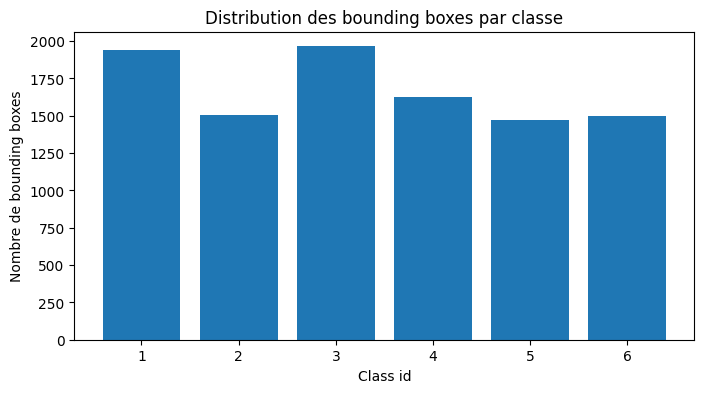

In [ ]:
import matplotlib.pyplot as plt

class_ids = sorted(cls_counter.keys())
counts = [cls_counter[c] for c in class_ids]

plt.figure(figsize=(8,4))
plt.bar([str(c) for c in class_ids], counts)
plt.xlabel("Class id")
plt.ylabel("Nombre de bounding boxes")
plt.title("Distribution des bounding boxes par classe")
plt.show()
plt.close()


- Les classes sont **relativement équilibrées**.
- Aucun déséquilibre critique détecté.
- Réduction du risque de biais vers une classe dominante.
- Meilleure stabilité durant l’entraînement.

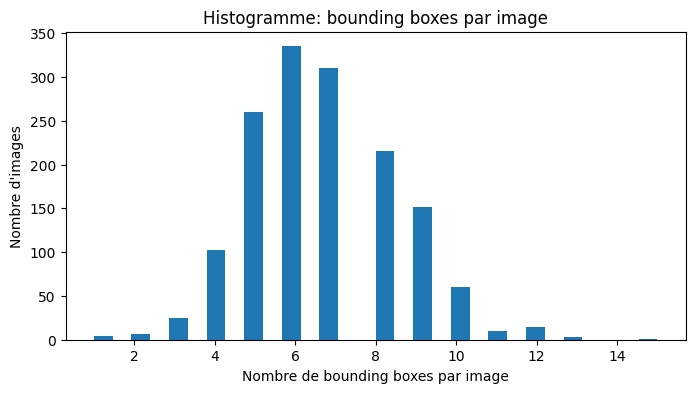

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(boxes_per_image, bins=30)
plt.xlabel("Nombre de bounding boxes par image")
plt.ylabel("Nombre d'images")
plt.title("Histogramme: bounding boxes par image")
plt.show()
plt.close()


- Distribution centrée et cohérente avec la moyenne.
- Légère asymétrie à droite (quelques images très denses).
- Le modèle devra gérer efficacement les scènes multi-objets.
- La Non-Max Suppression (NMS) sera importante pour éviter les détections multiples inutiles.

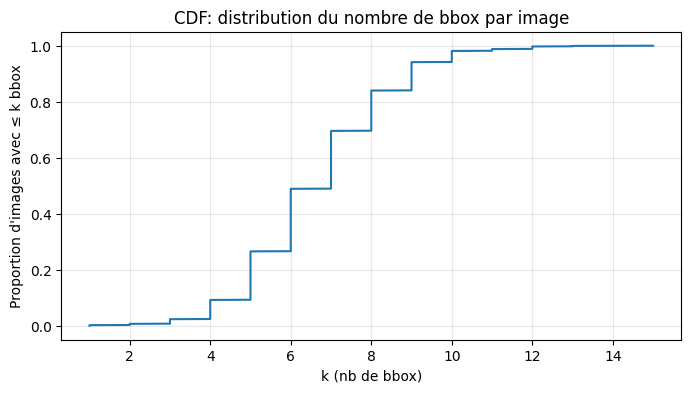

In [ ]:
sorted_boxes = np.sort(boxes_per_image)
cdf = np.arange(1, len(sorted_boxes)+1) / len(sorted_boxes)

plt.figure(figsize=(8,4))
plt.plot(sorted_boxes, cdf)
plt.xlabel("k (nb de bbox)")
plt.ylabel("Proportion d'images avec ≤ k bbox")
plt.title("CDF: distribution du nombre de bbox par image")
plt.grid(True, alpha=0.3)
plt.show()
plt.close()


- La majorité des images sont modérément denses.
- Les cas extrêmes (>12 objets) sont rares.
- Le dataset est homogène et stable.
- Peu de situations extrêmes susceptibles de déstabiliser le modèle.

In [ ]:
pairs = []
for img_path in images:
    lab_path = LABEL_DIR / f"{img_path.stem}.txt"
    n = len(read_rows(lab_path))
    pairs.append((n, img_path.name))

pairs.sort(reverse=True)
print("Top 10 images (plus de bbox):")
for n, name in pairs[:10]:
    print(name, "->", n)


Top 10 images (plus de bbox):
20085221.jpg -> 15
90100009.jpg -> 13
20085225.jpg -> 13
13000019.jpg -> 13
90100010.jpg -> 12
20085042.jpg -> 12
13000037.jpg -> 12
13000030.jpg -> 12
13000029.jpg -> 12
13000028.jpg -> 12


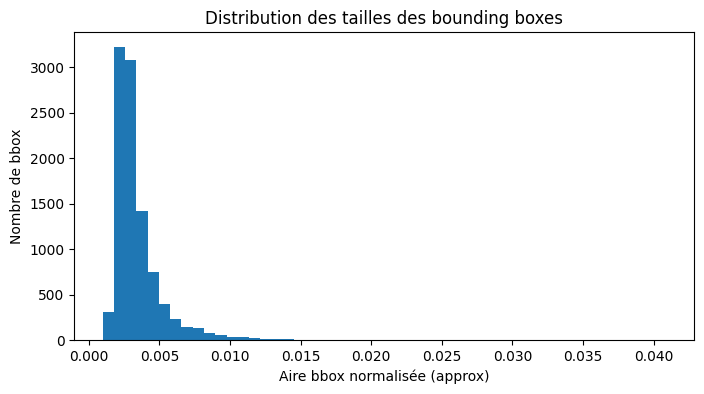

In [ ]:
if LABEL_FORMAT == "xyxycls":
    W, H = 640, 640
    areas = []
    for lab in labels:
        rows = read_rows(lab)
        for r in rows:
            if len(r) == 5:
                x1,y1,x2,y2,_ = r
                x1,y1,x2,y2 = map(float,(x1,y1,x2,y2))
                w = max(0, x2-x1)/W
                h = max(0, y2-y1)/H
                areas.append(w*h)
    areas = np.array(areas) if areas else np.array([0])

    plt.figure(figsize=(8,4))
    plt.hist(areas, bins=50)
    plt.xlabel("Aire bbox normalisée (approx)")
    plt.ylabel("Nombre de bbox")
    plt.title("Distribution des tailles des bounding boxes")
    plt.show()
    plt.close()


# 5) Visualisation des annotations (bbox + noms) — version low RAM (OpenCV)
On affiche 1 image, puis quelques exemples.


In [ ]:
!pip -q install opencv-python

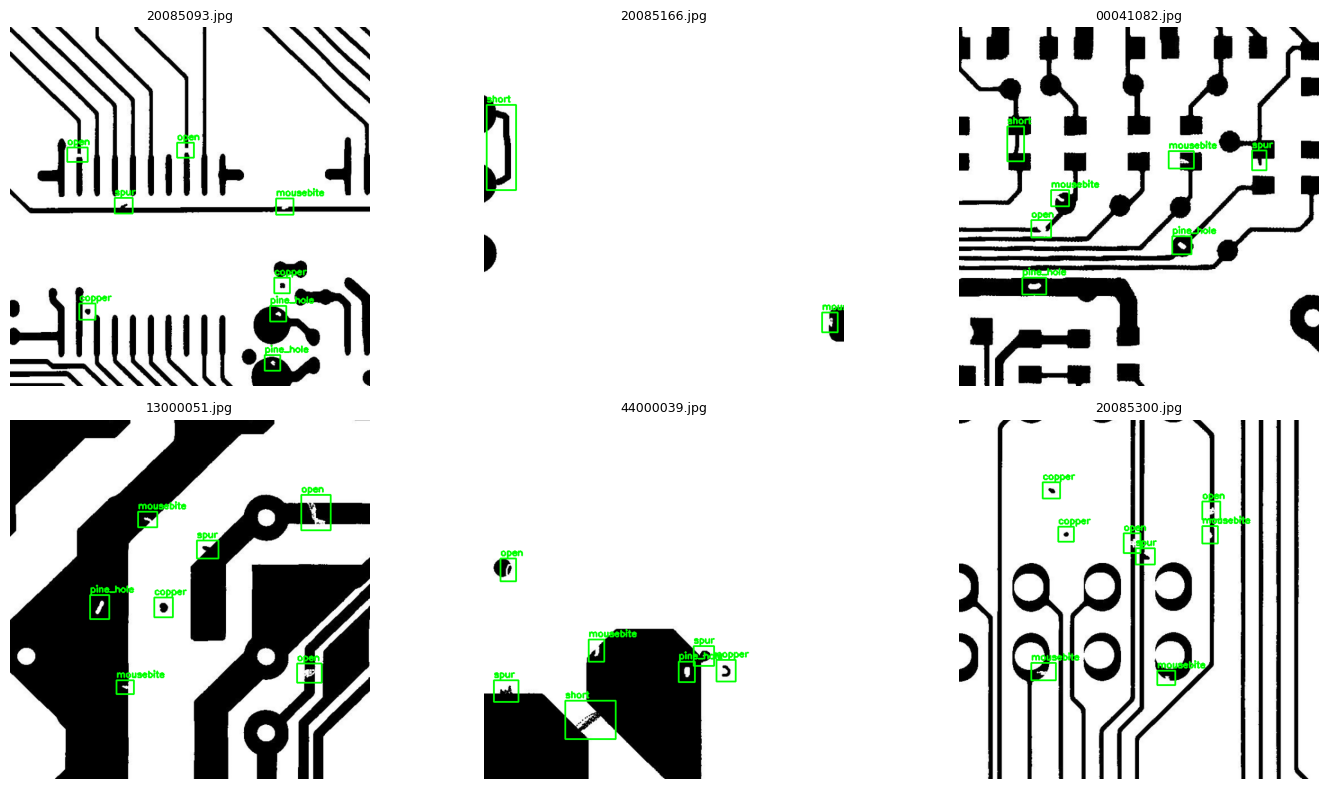

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

def show_grid(image_paths, rows=2, cols=3, max_side=600):
    fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
    axes = axes.flatten()

    for ax in axes:
        ax.axis("off")

    for ax, img_path in zip(axes, image_paths):
        lab_path = LABEL_DIR / f"{img_path.stem}.txt"
        img = cv2.imread(str(img_path))
        H0, W0 = img.shape[:2]

        # Resize safe
        scale = min(max_side / max(H0, W0), 1.0)
        if scale < 1.0:
            img = cv2.resize(img, (int(W0*scale), int(H0*scale)))

        H, W = img.shape[:2]

        rows_lab = read_rows(lab_path)

        for r in rows_lab:
            if len(r) != 5:
                continue

            if LABEL_FORMAT == "xyxycls":
                x1,y1,x2,y2,cls = r
                x1,y1,x2,y2 = map(float, (x1,y1,x2,y2))
                cls = int(float(cls))
                x1=int(x1*scale); y1=int(y1*scale)
                x2=int(x2*scale); y2=int(y2*scale)
            else:
                cls, xc, yc, bw, bh = r
                cls = int(float(cls))
                xc=float(xc); yc=float(yc); bw=float(bw); bh=float(bh)
                x1 = int((xc - bw/2) * W)
                y1 = int((yc - bh/2) * H)
                x2 = int((xc + bw/2) * W)
                y2 = int((yc + bh/2) * H)

            x1=max(0,min(x1,W-1)); x2=max(0,min(x2,W-1))
            y1=max(0,min(y1,H-1)); y2=max(0,min(y2,H-1))

            if LABEL_FORMAT == "xyxycls":
                idx = cls-1 if 1 <= cls <= NC else cls
            else:
                idx = cls

            name = NAMES_YOLO[idx] if 0 <= idx < NC else f"class_{cls}"

            cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)
            cv2.putText(img,name,(x1,max(15,y1-5)),
                        cv2.FONT_HERSHEY_SIMPLEX,0.5,(0,255,0),2)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(img_path.name, fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

random.seed(0)
sample_imgs = random.sample(images, k=min(6, len(images)))
show_grid(sample_imgs, rows=2, cols=3)



# 6) Conversion vers format YOLO (si nécessaire)
- Si le format détecté est **YOLO** : on saute cette étape.
- Si le format est **xyxycls** : on convertit vers `labels_yolo/` avec class_id en **0..(nc-1)**.


In [ ]:
import cv2, random

sample = random.sample(images, k=min(20, len(images)))
sizes = set()

for p in sample:
    im = cv2.imread(str(p))
    sizes.add(im.shape[:2])

print("Tailles trouvées (H,W):", sizes)

Tailles trouvées (H,W): {(640, 640)}


In [ ]:
from pathlib import Path

LABELS_YOLO = BASE / "labels_yolo"
LABELS_YOLO.mkdir(parents=True, exist_ok=True)

W, H = 640, 640

converted = 0
invalid = 0

for lab_in in LABEL_DIR.glob("*.txt"):
    rows = read_rows(lab_in)
    out_lines = []

    for r in rows:
        if len(r) != 5:
            invalid += 1
            continue

        x1,y1,x2,y2,cls = r
        x1,y1,x2,y2 = map(float,(x1,y1,x2,y2))
        cls = int(float(cls))

        cls_yolo = cls - 1
        if not (0 <= cls_yolo < NC):
            invalid += 1
            continue

        x1 = max(0, min(x1, W-1)); x2 = max(0, min(x2, W-1))
        y1 = max(0, min(y1, H-1)); y2 = max(0, min(y2, H-1))
        if x2 <= x1 or y2 <= y1:
            invalid += 1
            continue

        xc = ((x1 + x2) / 2) / W
        yc = ((y1 + y2) / 2) / H
        bw = (x2 - x1) / W
        bh = (y2 - y1) / H

        out_lines.append(f"{cls_yolo} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}")

    (LABELS_YOLO / lab_in.name).write_text("\n".join(out_lines) + ("\n" if out_lines else ""))
    converted += 1

print("Labels convertis:", converted)
print("Invalid:", invalid)
print("Sortie:", LABELS_YOLO)

Labels convertis: 1500
Invalid: 0
Sortie: /content/drive/MyDrive/COMPUTER VISION/dataset/labels_yolo


# 7) Préparer le dataset YOLO (split train/val/test)
Structure finale :

```
yolo_dataset/
images/train, images/val, images/test
labels/train, labels/val, labels/test
```

In [ ]:
import random, shutil
from pathlib import Path

OUT = BASE / "yolo_dataset"
for s in ["train","val","test"]:
    (OUT/"images"/s).mkdir(parents=True, exist_ok=True)
    (OUT/"labels"/s).mkdir(parents=True, exist_ok=True)

random.seed(42)
imgs = images[:]
random.shuffle(imgs)

n = len(imgs)
n_train = int(0.70*n)
n_val = int(0.15*n)

train_set = imgs[:n_train]
val_set = imgs[n_train:n_train+n_val]
test_set = imgs[n_train+n_val:]

# Choix des labels à copier (déjà YOLO ou convertis)
LABEL_SRC = LABEL_DIR if LABEL_FORMAT == "yolo" else LABELS_YOLO

def copy_to(split, img_path):
    shutil.copy2(img_path, OUT/"images"/split/img_path.name)
    lab = LABEL_SRC / f"{img_path.stem}.txt"
    shutil.copy2(lab, OUT/"labels"/split/lab.name)

for p in train_set: copy_to("train", p)
for p in val_set:   copy_to("val", p)
for p in test_set:  copy_to("test", p)

print("Split done")
print("Train:", len(train_set), "Val:", len(val_set), "Test:", len(test_set))
print("Dataset YOLO:", OUT)

Split done
Train: 1050 Val: 225 Test: 225
Dataset YOLO: /content/drive/MyDrive/COMPUTER VISION/dataset/yolo_dataset


# 8) Créer le fichier YAML (pcb.yaml)
Nécessaire pour YOLOv8.


In [ ]:
YAML_PATH = BASE / "pcb.yaml"
OUT = BASE / "yolo_dataset"

YAML_PATH.write_text(
f"""path: {OUT}
train: images/train
val: images/val
test: images/test

nc: {NC}
names: {NAMES_YOLO}
"""
)

print("YAML créé:", YAML_PATH)
print(YAML_PATH.read_text())

YAML créé: /content/drive/MyDrive/COMPUTER VISION/dataset/pcb.yaml
path: /content/drive/MyDrive/COMPUTER VISION/dataset/yolo_dataset
train: images/train
val: images/val
test: images/test

nc: 6
names: ['open', 'short', 'mousebite', 'spur', 'copper', 'pine_hole']



# 9) Entraînement YOLOv8 (Transfer Learning / Fine-tuning)
Modèle pré-entraîné: yolov8n.pt


## Hyperparamètres (choix & justifications)

- **Modèle**: YOLOv8n (léger, adapté à un dataset de taille modérée et permet des itérations rapides).
- **Transfer learning**: poids pré-entraînés COCO (`yolov8n.pt`) pour améliorer la généralisation.
- **imgsz = 640**: taille standard YOLO, bon compromis précision / coût.
- **batch = 16**: compromis entre stabilité d’optimisation et mémoire GPU.
- **epochs = 40**: suffisant pour converger; contrôlé avec **early stopping**.
- **patience = 10**: stop si la validation n’améliore plus, limite le sur-apprentissage.

In [ ]:
!pip -q install ultralytics

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # léger

results = model.train(
    data=str(YAML_PATH),
    imgsz=640,
    epochs=40,
    batch=16,
    patience=10
)

Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/COMPUTER VISION/dataset/pcb.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True,

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

_candidates = [
    BASE / "training_outputs_run1" / "results.csv",
    BASE / "training_outputs"      / "results.csv",
    Path("/content/runs/detect/train/results.csv"),
]
csv_path = next((p for p in _candidates if p.exists()), None)
assert csv_path is not None, "results.csv introuvable. Vérifiez que training_outputs_run1/results.csv existe sur le Drive."
print("results.csv trouvé :", csv_path)

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

print("=== Résultats epoch par epoch ===")
display(df[["epoch",
             "metrics/precision(B)", "metrics/recall(B)",
             "metrics/mAP50(B)", "metrics/mAP50-95(B)",
             "train/box_loss","train/cls_loss","train/dfl_loss",
             "val/box_loss","val/cls_loss","val/dfl_loss"]].tail(15))

best_row = df.loc[df["metrics/mAP50(B)"].idxmax()]
print("\n=== Meilleure epoch ===")
print(f"Epoch          : {int(best_row['epoch'])}")
print(f"Precision      : {best_row['metrics/precision(B)']:.4f}")
print(f"Recall         : {best_row['metrics/recall(B)']:.4f}")
print(f"mAP@0.5        : {best_row['metrics/mAP50(B)']:.4f}")
print(f"mAP@0.5:0.95   : {best_row['metrics/mAP50-95(B)']:.4f}")

results.csv trouvé : /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/results.csv
=== Résultats epoch par epoch ===


,epoch,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),train/box_loss,train/cls_loss,train/dfl_loss,val/box_loss,val/cls_loss,val/dfl_loss
24,25,0.97405,0.93688,0.98157,0.68452,1.01923,0.65256,0.92400,0.98409,0.52127,0.92520
25,26,0.96723,0.94580,0.98121,0.75374,0.99324,0.64164,0.91502,0.83752,0.47246,0.89827
26,27,0.98446,0.94255,0.98284,0.65426,1.00031,0.63990,0.91975,1.08076,0.52620,0.94877
27,28,0.97521,0.94823,0.98090,0.60878,1.01086,0.64039,0.91946,1.27608,0.55356,0.99175
28,29,0.97471,0.95294,0.98198,0.76447,0.99483,0.61269,0.91785,0.80072,0.45595,0.88845
29,30,0.97565,0.94102,0.97604,0.55273,0.98729,0.60492,0.91353,1.48271,0.59710,1.04707
30,31,0.96774,0.95185,0.98008,0.74146,0.97461,0.56947,0.92018,0.86325,0.46331,0.90007
31,32,0.97857,0.95116,0.98263,0.68878,0.95389,0.54594,0.91819,1.00054,0.49393,0.92836
32,33,0.97976,0.95672,0.98424,0.67489,0.89709,0.52556,0.90879,1.06251,0.49306,0.93442
33,34,0.98495,0.95445,0.98485,0.67914,0.88283,0.51237,0.90772,1.05089,0.49259,0.93779



=== Meilleure epoch ===
Epoch          : 39
Precision      : 0.9833
Recall         : 0.9586
mAP@0.5        : 0.9867
mAP@0.5:0.95   : 0.7499


results.csv trouvé : /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/results.csv


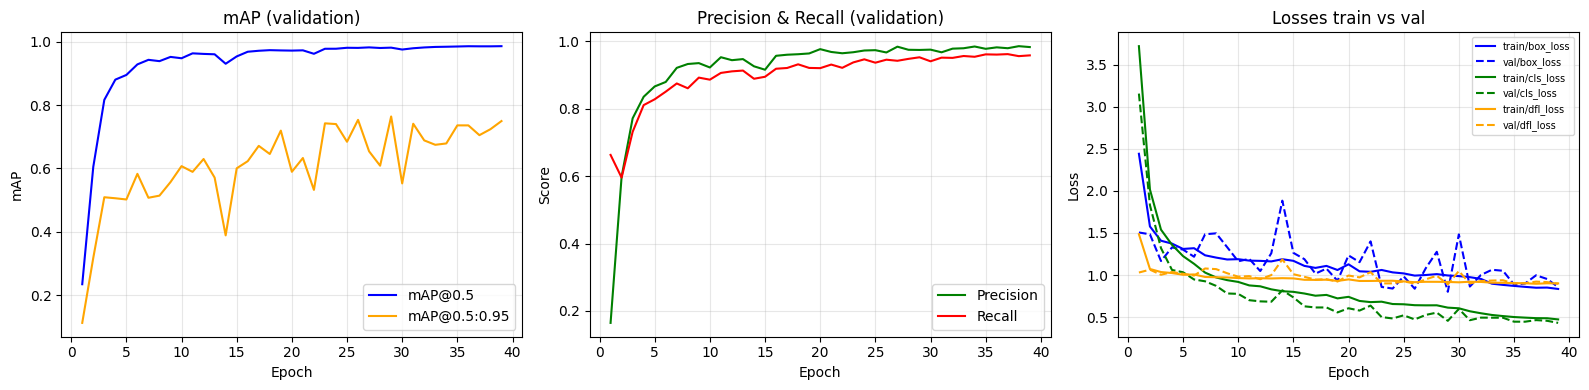

Courbes sauvegardées.


In [ ]:
# Courbes d'entraînement : mAP, losses train ET val
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

_candidates = [
    BASE / "training_outputs_run1" / "results.csv",
    BASE / "training_outputs"      / "results.csv",
    Path("/content/runs/detect/train/results.csv"),
]
csv_path = next((p for p in _candidates if p.exists()), None)
assert csv_path is not None, "results.csv introuvable sur le Drive."
print("results.csv trouvé :", csv_path)

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# mAP@0.5
axes[0].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP@0.5", color="blue")
axes[0].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95", color="orange")
axes[0].set_title("mAP (validation)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("mAP")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Precision & Recall
axes[1].plot(df["epoch"], df["metrics/precision(B)"], label="Precision", color="green")
axes[1].plot(df["epoch"], df["metrics/recall(B)"], label="Recall", color="red")
axes[1].set_title("Precision & Recall (validation)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Train vs Val Loss
axes[2].plot(df["epoch"], df["train/box_loss"], label="train/box_loss", color="blue")
axes[2].plot(df["epoch"], df["val/box_loss"],   label="val/box_loss",   color="blue",   linestyle="--")
axes[2].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss", color="green")
axes[2].plot(df["epoch"], df["val/cls_loss"],   label="val/cls_loss",   color="green",  linestyle="--")
axes[2].plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss", color="orange")
axes[2].plot(df["epoch"], df["val/dfl_loss"],   label="val/dfl_loss",   color="orange", linestyle="--")
axes[2].set_title("Losses train vs val")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Loss")
axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()
print("Courbes sauvegardées.")

 Dossier trouvé : /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1
Fichiers disponibles : ['BoxPR_curve.png', 'BoxF1_curve.png', 'BoxR_curve.png', 'BoxP_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png']


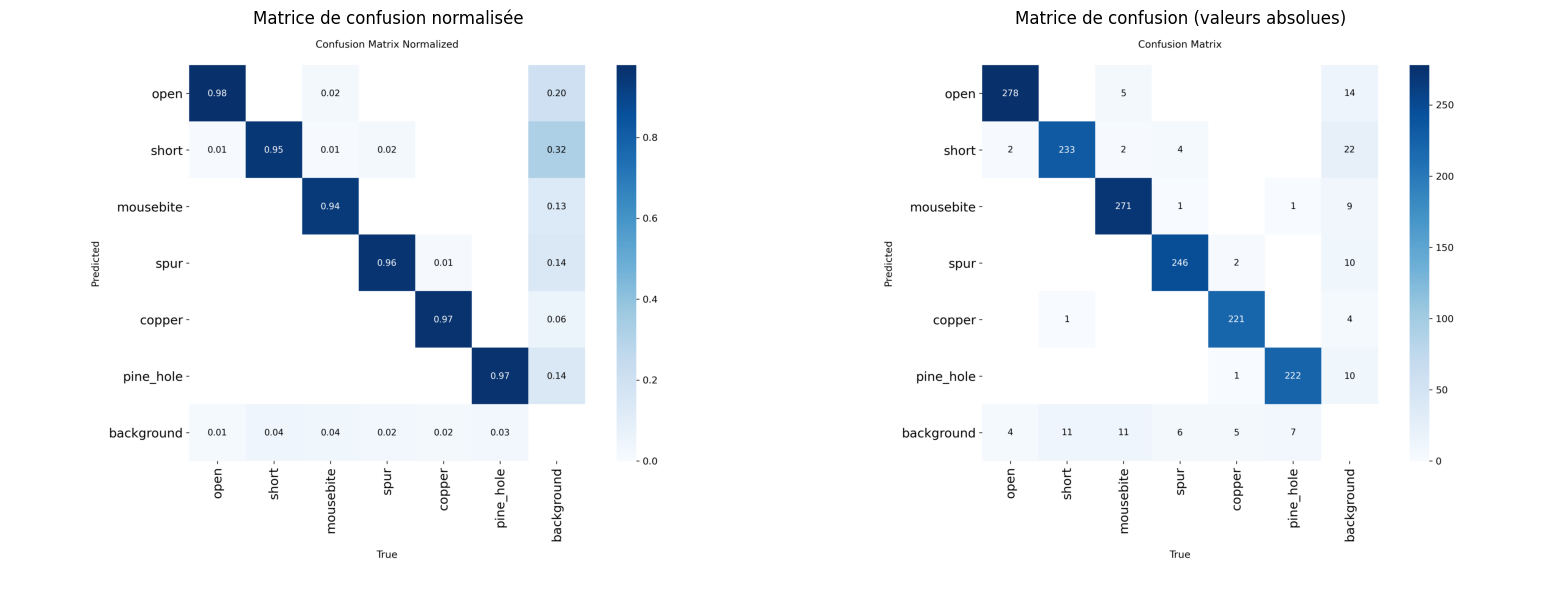

In [ ]:
# Affichage de la matrice de confusion
import cv2, matplotlib.pyplot as plt
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

# Cherche le dossier contenant les matrices de confusion
_candidates = [
    BASE / "training_outputs_run1",
    BASE / "training_outputs",
    BASE / "evaluation_outputs_test" / "val",
    Path("/content/runs/detect/train"),
    Path("/content/runs/detect/val"),
]
run_dir = next((p for p in _candidates if p.exists() and list(p.glob("confusion_matrix*.png"))), None)

if run_dir is None:
    print("Aucun dossier contenant confusion_matrix*.png trouvé.")
    print("Dossiers vérifiés :")
    for p in _candidates:
        print(f"  {p}  →  existe={p.exists()}")
else:
    print(" Dossier trouvé :", run_dir)
    print("Fichiers disponibles :", [f.name for f in run_dir.glob("*.png")])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, fname, title in [
        (axes[0], "confusion_matrix_normalized.png", "Matrice de confusion normalisée"),
        (axes[1], "confusion_matrix.png",             "Matrice de confusion (valeurs absolues)"),
    ]:
        p = run_dir / fname
        if p.exists():
            img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(title, fontsize=12)
            ax.axis("off")
        else:
            ax.text(0.5, 0.5, f"Fichier introuvable :\n{fname}",
                    ha="center", va="center", transform=ax.transAxes, color="red")
            ax.axis("off")

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

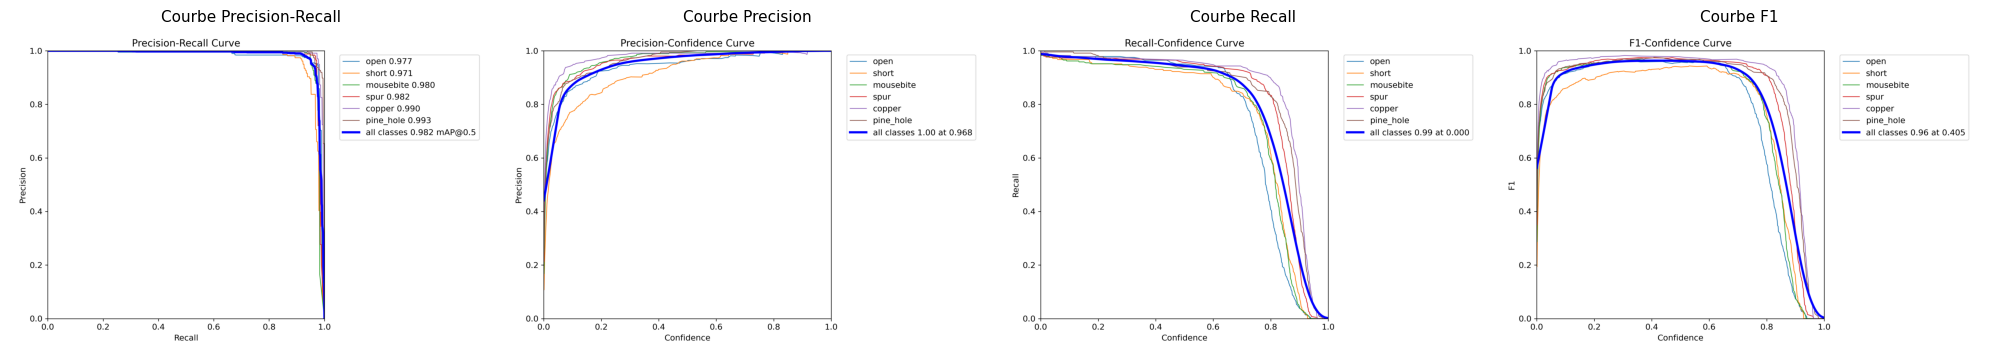

In [ ]:
# Affichage des courbes PR, P, R, F1
import cv2, matplotlib.pyplot as plt
from pathlib import Path

BASE    = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")
run_dir = BASE / "training_outputs_run1"

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, fname, title in [
    (axes[0], "BoxPR_curve.png", "Courbe Precision-Recall"),
    (axes[1], "BoxP_curve.png",  "Courbe Precision"),
    (axes[2], "BoxR_curve.png",  "Courbe Recall"),
    (axes[3], "BoxF1_curve.png", "Courbe F1"),
]:
    p = run_dir / fname
    if p.exists():
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Introuvable :\n{fname}",
                ha="center", va="center", transform=ax.transAxes, color="red")
        ax.axis("off")

plt.tight_layout()
plt.savefig("pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# Résultats (Validation) — Meilleur modèle

EarlyStopping : arrêt automatique sans amélioration pendant 10 epochs.  
Meilleur modèle sauvegardé à l'epoch **29** (`best.pt`).

Sur le split validation (225 images, 1534 instances) :
- **Precision (P)** = 0.973
- **Recall (R)** = 0.955
- **mAP@0.5** = 0.982
- **mAP@0.5:0.95** = 0.765

Résultats par classe :
- open: mAP50=0.977 ; mAP50-95=0.691
- short: mAP50=0.971 ; mAP50-95=0.668
- mousebite: mAP50=0.980 ; mAP50-95=0.740
- spur: mAP50=0.982 ; mAP50-95=0.753
- copper: mAP50=0.990 ; mAP50-95=0.880
- pine_hole: mAP50=0.993 ; mAP50-95=0.856

# 10) Sauvegarder le meilleur modèle (best.pt) sur Drive


In [ ]:
import shutil
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

run_dir = Path("/content/runs/detect/train")
assert run_dir.exists(), f"Run dir introuvable: {run_dir}"

EXPORT_DIR = BASE / "training_outputs_run1"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# copier tout le dossier du run (figures + csv + weights)
shutil.copytree(run_dir, EXPORT_DIR, dirs_exist_ok=True)

print("Run exporté dans Drive:", EXPORT_DIR)
print("Poids:", list((EXPORT_DIR/"weights").glob("*.pt")))

Run exporté dans Drive: /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1
Poids: [PosixPath('/content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/last.pt'), PosixPath('/content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/best.pt')]


In [ ]:
for p in BASE.rglob("best.pt"):
    print(p)

/content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/best.pt


In [ ]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

print("Contenu du dossier dataset :")
for p in BASE.iterdir():
    print("-", p.name)

Contenu du dossier dataset :
- annotation
- img
- labels_yolo
- yolo_dataset
- pcb.yaml
- training_outputs
- training_outputs_run1


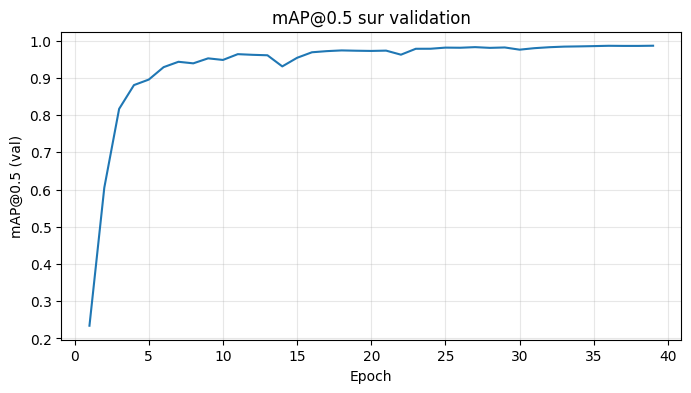

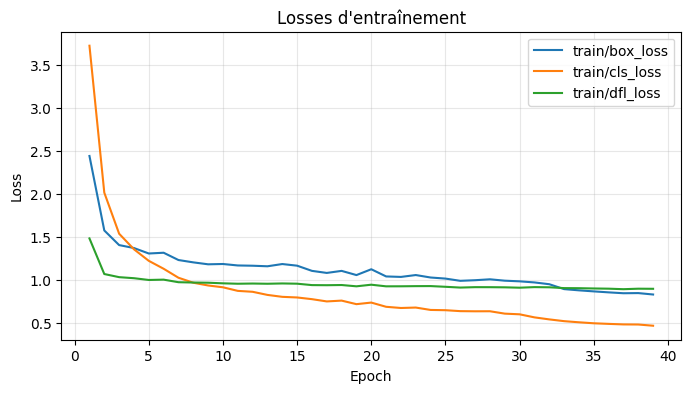

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("/content/runs/detect/train/results.csv")
df = pd.read_csv(csv_path)

# mAP50
plt.figure(figsize=(8,4))
plt.plot(df["epoch"], df["metrics/mAP50(B)"])
plt.xlabel("Epoch")
plt.ylabel("mAP@0.5 (val)")
plt.title("mAP@0.5 sur validation")
plt.grid(True, alpha=0.3)
plt.show()
plt.close()

# losses
plt.figure(figsize=(8,4))
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
plt.plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Losses d'entraînement")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
plt.close()

##  Évolution de la mAP@0.5
- Le modèle converge rapidement.
- Dataset bien annoté.
- Modèle adapté à la tâche.
- Aucun signe évident d’overfitting visible.

## Évolution des losses (box, cls, dfl)

- Optimisation stable.
- Apprentissage progressif des localisations.
- Bonne séparation des classes.
- Pas d’instabilité ou divergence observée.

In [ ]:
from pathlib import Path
BEST_MODEL = Path("/content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/best.pt")
print("Modèle final (Drive):", BEST_MODEL, "| exists:", BEST_MODEL.exists())

Modèle final (Drive): /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs_run1/weights/best.pt | exists: True


In [ ]:
import shutil
from pathlib import Path

BASE = Path("/content/drive/MyDrive/COMPUTER VISION/dataset")

run_dir = Path("/content/runs/detect/train")
assert run_dir.exists(), f"Run introuvable: {run_dir}"

EXPORT_DIR = BASE / "training_outputs"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copier les poids
best_src = run_dir / "weights" / "best.pt"
last_src = run_dir / "weights" / "last.pt"

if best_src.exists():
    shutil.copy2(best_src, EXPORT_DIR / "best.pt")
else:
    print(" best.pt introuvable:", best_src)

if last_src.exists():
    shutil.copy2(last_src, EXPORT_DIR / "last.pt")
else:
    print(" last.pt introuvable:", last_src)

# Copier les fichiers utiles
files_to_copy = [
    "results.csv",
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
    "PR_curve.png",
    "P_curve.png",
    "R_curve.png",
    "F1_curve.png",
]

for fn in files_to_copy:
    src = run_dir / fn
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / fn)

print(" Export terminé vers:", EXPORT_DIR)
print("Contenu exporté:", sorted([p.name for p in EXPORT_DIR.iterdir()]))

 Export terminé vers: /content/drive/MyDrive/COMPUTER VISION/dataset/training_outputs
Contenu exporté: ['best.pt', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'labels.jpg', 'last.pt', 'results.csv', 'results.png']


## Justification du split 70/15/15
Le dataset contient **1500 images** réparties comme suit :
- **Train (70% = 1050 images)** : suffisant pour apprendre les features visuelles des 6 classes de défauts PCB.
- **Validation (15% = 225 images)** : permet de monitorer l'overfitting epoch par epoch et de sélectionner le meilleur modèle (early stopping).
- **Test (15% = 225 images)** : réservé uniquement à l'évaluation finale, jamais vu pendant l'entraînement.

Ce split est standard pour des datasets de taille intermédiaire (~1000–5000 exemples). Un split 80/10/10 aurait aussi été possible mais nous préférons avoir suffisamment d'exemples dans val et test pour des estimations de métriques stables.


# Conclusion (Notebook 1)

Ce notebook a permis de :
- Vérifier la cohérence du dataset (images ↔ annotations) et analyser sa distribution.
- Préparer le dataset au format YOLO (train/val/test + `pcb.yaml`).
- Entraîner un modèle YOLOv8 par transfer learning (fine-tuning).
- Sauvegarder les poids du meilleur modèle (`best.pt`) et les courbes/métriques d’entraînement.

Le Notebook 2 sera dédié à l’évaluation finale sur le **jeu de test** :
- métriques quantitatives (mAP@0.5, Precision, Recall, par classe)
- analyse qualitative (cas réussis / erreurs)
- analyse des limites et erreurs courantes.